# A* Algorithm


Path:
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (3, 4), (4, 4)]


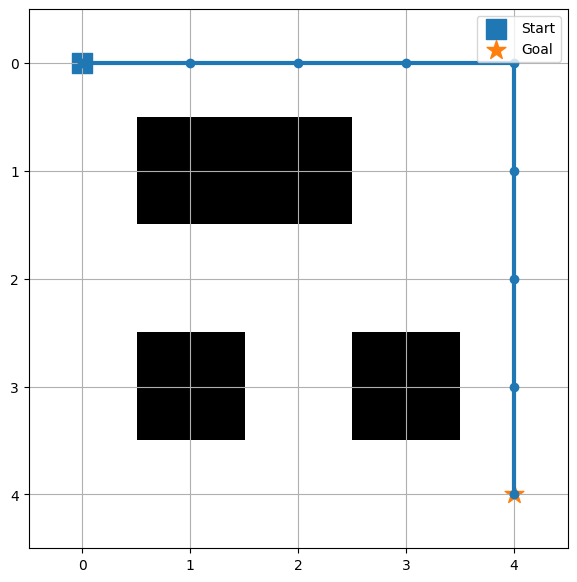

In [27]:
import heapq
import matplotlib.pyplot as plt
grid = [
    [0, 0, 0, 0, 0],
    [0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0]
]
start = (0, 0)
goal = (4, 4)
def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])
def astar(grid, start, goal):
    rows = len(grid)
    cols = len(grid[0])
    open_list = []
    heapq.heappush(open_list, (0, start))
    came_from = {}
    g_score = {start: 0}

    f_score = {
        start: heuristic(start, goal)
    }
    directions = [
        (-1, 0),
        (1, 0),
        (0, -1),
        (0, 1)
    ]
    while open_list:
        current_f, current = heapq.heappop(open_list)
        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            path.reverse()
            return path
        r, c = current
        for dr, dc in directions:
            nr = r + dr
            nc = c + dc

            if (
                0 <= nr < rows
                and 0 <= nc < cols
                and grid[nr][nc] == 0
            ):
                neighbor = (nr, nc)

                tentative_g = g_score[current] + 1

                if tentative_g < g_score.get(
                    neighbor, float("inf")
                ):
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g

                    f = (
                        tentative_g
                        + heuristic(neighbor, goal)
                    )
                    f_score[neighbor] = f
                    heapq.heappush(
                        open_list,
                        (f, neighbor)
                    )
    return None
path = astar(grid, start, goal)
print("Path:")
print(path)
def visualize_grid(grid, path, start, goal):
    plt.figure(figsize=(7, 7))
    plt.imshow(grid, cmap="gray_r")
    if path:
        x = [p[1] for p in path]
        y = [p[0] for p in path]
        plt.plot(
            x,
            y,
            marker="o",
            linewidth=3
        )
    plt.scatter(
        start[1],
        start[0],
        s=200,
        marker="s",
        label="Start"
    )
    plt.scatter(
        goal[1],
        goal[0],
        s=200,
        marker="*",
        label="Goal"
    )
    plt.xticks(range(len(grid[0])))
    plt.yticks(range(len(grid)))
    plt.grid(True)
    plt.legend()
    plt.show()
visualize_grid(grid, path, start, goal)
            

# A* Algorithm using Other Path

Best Path:
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (1, 6), (2, 6), (3, 6), (4, 6), (5, 6), (6, 6)]
Path Cost: 12


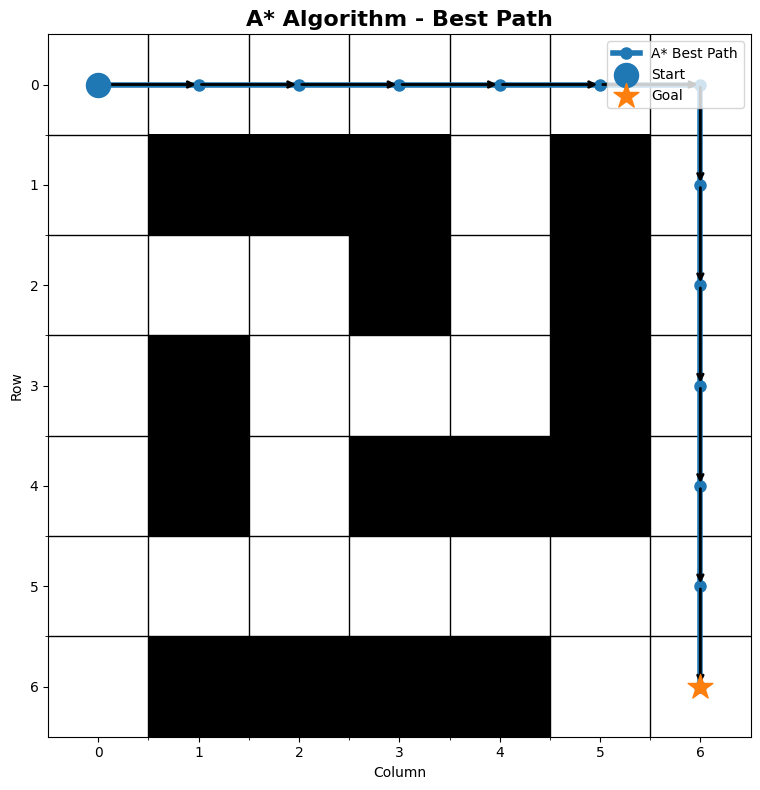

In [29]:
import heapq
import matplotlib.pyplot as plt
grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 1, 0],
    [0, 1, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0]
]
start = (0, 0)
goal = (6, 6)
def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])
def astar(grid, start, goal):
    rows = len(grid)
    cols = len(grid[0])
    open_list = []
    heapq.heappush(
        open_list,
        (heuristic(start, goal), 0, start)
    )
    came_from = {}
    g_score = {
        start: 0
    }
    directions = [
        (-1, 0),
        (1, 0),
        (0, -1),
        (0, 1)
    ]
    while open_list:
        current_f, current_g, current = heapq.heappop(open_list)
        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            path.reverse()
            return path
        r, c = current
        for dr, dc in directions:
            nr = r + dr
            nc = c + dc
            if (
                0 <= nr < rows
                and 0 <= nc < cols
                and grid[nr][nc] == 0
            ):
                neighbor = (nr, nc)

                tentative_g = g_score[current] + 1

                if tentative_g < g_score.get(
                    neighbor,
                    float("inf")
                ):
                    came_from[neighbor] = current

                    g_score[neighbor] = tentative_g

                    f_score = (
                        tentative_g
                        + heuristic(neighbor, goal)
                    )

                    heapq.heappush(
                        open_list,
                        (f_score, tentative_g, neighbor)
                    )

    return None
path = astar(grid, start, goal)
print("Best Path:")
print(path)
if path:
    print("Path Cost:", len(path) - 1)
else:
    print("No path found")
def visualize_grid(grid, path, start, goal):
    fig, ax = plt.subplots(figsize=(8, 8))
    rows = len(grid)
    cols = len(grid[0])
    ax.imshow(
        grid,
        cmap="Greys",
        origin="upper"
    )

    ax.set_xticks(range(cols))
    ax.set_yticks(range(rows))
    ax.set_xticks(
        [x - 0.5 for x in range(1, cols)],
        minor=True
    )
    ax.set_yticks(
        [y - 0.5 for y in range(1, rows)],
        minor=True
    )
    ax.grid(
        which="minor",
        color="black",
        linewidth=1
    )
    if path:

        x = [p[1] for p in path]
        y = [p[0] for p in path]
        ax.plot(
            x,
            y,
            marker="o",
            markersize=8,
            linewidth=4,
            label="A* Best Path"
        )
        for i in range(len(path) - 1):

            x1, y1 = path[i][1], path[i][0]
            x2, y2 = path[i + 1][1], path[i + 1][0]
            ax.annotate(
                "",
                xy=(x2, y2),
                xytext=(x1, y1),
                arrowprops=dict(
                    arrowstyle="->",
                    linewidth=2
                )
            )
    ax.scatter(
        start[1],
        start[0],
        s=300,
        marker="o",
        label="Start",
        zorder=5
    )
    ax.scatter(
        goal[1],
        goal[0],
        s=350,
        marker="*",
        label="Goal",
        zorder=5
    )
    ax.set_title(
        "A* Algorithm - Best Path",
        fontsize=16,
        fontweight="bold"
    )
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    ax.legend(
        loc="upper right"
    )
    plt.tight_layout()
    plt.show()
visualize_grid(
    grid,
    path,
    start,
    goal
)

# 8 Puzzle Problem Using Heuristic

Solution Found!
Total Moves: 2


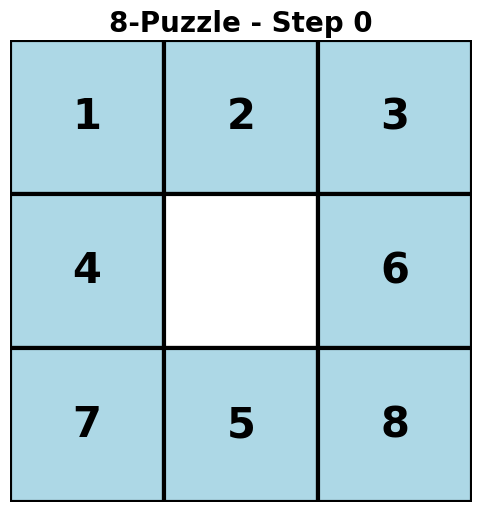

In [28]:
import heapq
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
goal = (
    1, 2, 3,
    4, 5, 6,
    7, 8, 0
)
def heuristic(state):
    distance = 0
    for i in range(9):
        if state[i] != 0:
            current_row = i // 3
            current_col = i % 3
            goal_index = goal.index(state[i])
            goal_row = goal_index // 3
            goal_col = goal_index % 3
            distance += abs(current_row - goal_row)
            distance += abs(current_col - goal_col)
    return distance
def get_neighbors(state):
    neighbors = []
    zero_index = state.index(0)
    row = zero_index // 3
    col = zero_index % 3
    moves = [
        (-1, 0),
        (1, 0),
        (0, -1),
        (0, 1)
    ]
    for dr, dc in moves:
        new_row = row + dr
        new_col = col + dc
        if 0 <= new_row < 3 and 0 <= new_col < 3:
            new_index = new_row * 3 + new_col
            new_state = list(state)
            new_state[zero_index], new_state[new_index] = \
                new_state[new_index], new_state[zero_index]
            neighbors.append(tuple(new_state))
    return neighbors
def solve_8_puzzle(start):
    priority_queue = []
    g_score = {start: 0}
    parent = {start: None}
    f_score = heuristic(start)
    heapq.heappush(
        priority_queue,
        (f_score, 0, start)
    )
    visited = set()
    while priority_queue:
        f, g, current = heapq.heappop(priority_queue)
        if current in visited:
            continue
        visited.add(current)
        if current == goal:
            path = []
            while current is not None:
                path.append(current)
                current = parent[current]
            path.reverse()
            return path
        for neighbor in get_neighbors(current):

            if neighbor in visited:
                continue
            new_g = g + 1
            if new_g < g_score.get(
                neighbor,
                float("inf")
            ):
                g_score[neighbor] = new_g
                parent[neighbor] = current
                f = new_g + heuristic(neighbor)
                heapq.heappush(
                    priority_queue,
                    (f, new_g, neighbor)
                )
    return None
def draw_puzzle(ax, state, step, total_steps):
    ax.clear()
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    ax.set_aspect("equal")
    ax.axis("off")
    for i, value in enumerate(state):
        row = 2 - (i // 3)
        col = i % 3
        if value != 0:
            rectangle = Rectangle(
                (col, row),
                1,
                1,
                linewidth=3,
                edgecolor="black",
                facecolor="lightblue"
            )
            ax.add_patch(rectangle)
            ax.text(
                col + 0.5,
                row + 0.5,
                str(value),
                fontsize=30,
                fontweight="bold",
                ha="center",
                va="center"
            )
        else:
            rectangle = Rectangle(
                (col, row),
                1,
                1,
                linewidth=3,
                edgecolor="black",
                facecolor="white"
            )
            ax.add_patch(rectangle)
    if step == total_steps:
        ax.set_title(
            "GOAL STATE",
            fontsize=20,
            fontweight="bold"
        )
    else:
        ax.set_title(
            f"8-Puzzle - Step {step}",
            fontsize=20,
            fontweight="bold"
        )
start = (
    1, 2, 3,
    4, 0, 6,
    7, 5, 8
)
path = solve_8_puzzle(start)

if path:
    print("Solution Found!")
    print("Total Moves:", len(path) - 1)
    plt.ion()
    fig, ax = plt.subplots(
        figsize=(6, 6)
    )
    for step, state in enumerate(path):
        draw_puzzle(
            ax,
            state,
            step,
            len(path) - 1
        )
        plt.pause(1)
    plt.ioff()
    plt.show()
else:
    print("No solution found!")